In [1]:
# 01 – Exploratory Data Analysis: PhreshPhish

# **Goal**: Explore the large-scale real-world PhreshPhish dataset from Hugging Face without downloading the full dataset to disk.

# - Load via `datasets` (streaming preferred)
# - Inspect schema, labels, languages, URL/HTML statistics
# - Class balance & basic quality checks
# - No sample/synthetic data creation

In [2]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

from datasets import load_dataset, disable_caching
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm
import re
from urllib.parse import urlparse

# Optional: disable HF caching if you want pure streaming
# disable_caching()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
## 1. Load Dataset (Streaming)

DATASET_NAME = "phreshphish/phreshphish"

# Streaming mode – never materialises the full ~36 GB dataset
ds_stream = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True,
    trust_remote_code=False
)

print("Streaming dataset ready.")
print("Features:", ds_stream.features)

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/56 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Streaming dataset ready.
Features: {'sha256': Value('large_string'), 'url': Value('large_string'), 'label': Value('large_string'), 'target': Value('large_string'), 'date': Value('date32'), 'lang': Value('large_string'), 'lang_score': Value('float32'), 'html': Value('large_string')}


In [4]:
# ------------------------------------------------------------------
# Memory-safe sampling for EDA
# ------------------------------------------------------------------
N_SAMPLES = 10_000

print(f"Collecting {N_SAMPLES} samples (streaming, html truncated)...")

rows = []
for i, example in enumerate(tqdm(ds_stream, total=N_SAMPLES)):
    if i >= N_SAMPLES:
        break

    # Keep only light columns + a short html preview
    row = {
        "sha256"     : example.get("sha256"),
        "url"        : example.get("url"),
        "label"      : example.get("label"),
        "target"     : example.get("target"),
        "date"       : example.get("date"),
        "lang"       : example.get("lang"),
        "lang_score" : example.get("lang_score"),
        # Truncate html aggressively – we only need length + a preview
        "html_len"   : len(example.get("html") or ""),
        "html_preview": (example.get("html") or "")[:400],   # 400 chars max
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(f"Collected DataFrame shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(3)

  0%|          | 0/10000 [00:00<?, ?it/s]

Collected DataFrame shape: (10000, 9)
Memory usage: 9.0 MB


,sha256,url,label,target,date,lang,lang_score,html_len,html_preview
0,e5bf57080abb02f77b6f1767a26c19f2ea026d1d553cb8...,https://www.lifeonthemediterranean.com/portofi...,benign,None,2025-08-03,en,0.943381,518982,"<html lang=""en-US""><head><meta charset=""UTF-8""..."
1,c4dc9cb6d437aea7bbf4c920db29ca76489a1c4a37d02a...,https://moneypuck.com/goalies.htm,benign,None,2025-09-02,en,0.339514,192077,"<html lang=""en""><head>\n <meta http-equ..."
2,ee88be4f7636a2377b77aeac25dc81050d1a34f18e585b...,https://learn.microsoft.com/en-us/azure/defend...,benign,None,2024-09-13,en,0.853031,164883,"<html class=""hasSidebar hasPageActions hasBrea..."


In [5]:
## 2. Basic Schema & Missing Values
print("Columns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nLabel distribution:")
print(df["label"].value_counts(dropna=False))
print("\nLabel percentages:")
print(df["label"].value_counts(normalize=True).round(4) * 100)

Columns: ['sha256', 'url', 'label', 'target', 'date', 'lang', 'lang_score', 'html_len', 'html_preview']

Dtypes:
 sha256           object
url              object
label            object
target           object
date             object
lang             object
lang_score      float64
html_len          int64
html_preview     object
dtype: object

Missing values:
 sha256             0
url                0
label              0
target          5522
date               0
lang             215
lang_score         0
html_len           0
html_preview       0
dtype: int64

Label distribution:
label
benign    5525
phish     4475
Name: count, dtype: int64

Label percentages:
label
benign    55.25
phish     44.75
Name: proportion, dtype: float64


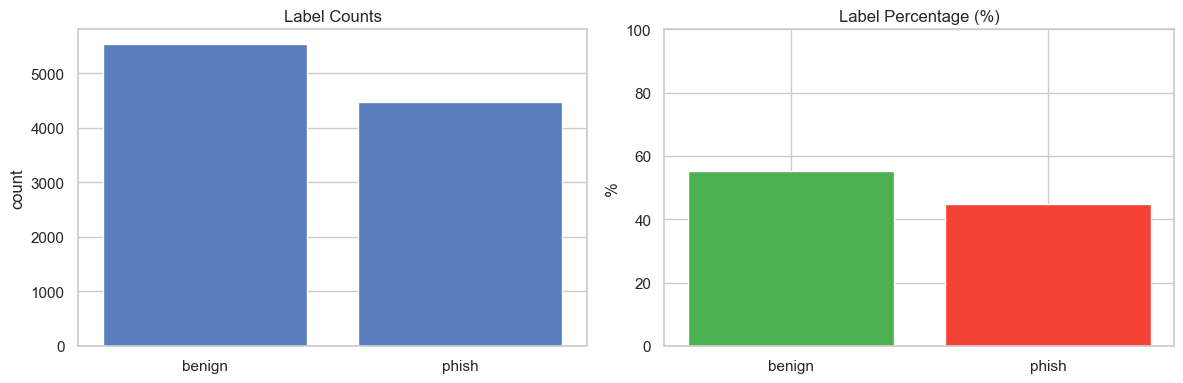

In [6]:
## 3. Class Balance Visualisation
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Counts
sns.countplot(data=df, x="label", ax=ax[0], order=["benign", "phish"])
ax[0].set_title("Label Counts")
ax[0].set_xlabel("")

# Percentages
perc = df["label"].value_counts(normalize=True)
ax[1].bar(perc.index, perc.values * 100, color=["#4caf50", "#f44336"])
ax[1].set_title("Label Percentage (%)")
ax[1].set_ylabel("%")
ax[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

Top languages:
 lang
en    8350
ja     654
fr     157
it     102
es      94
de      91
pt      67
ru      36
nl      30
pl      27
ko      26
tr      23
sv      17
th      15
zh      13
Name: count, dtype: int64


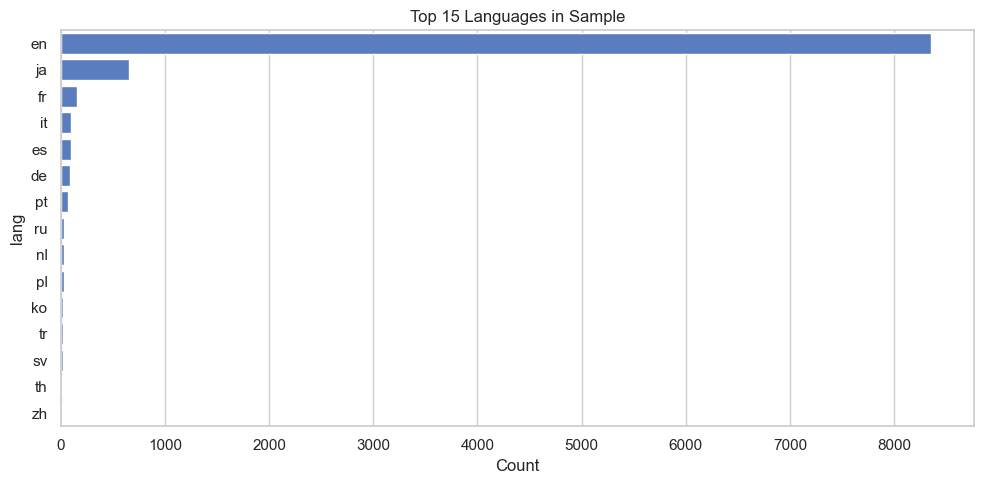

In [7]:
## 4. Language Distribution

if "lang" in df.columns:
    lang_counts = df["lang"].value_counts().head(15)
    print("Top languages:\n", lang_counts)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=lang_counts.values, y=lang_counts.index, orient="h")
    plt.title("Top 15 Languages in Sample")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'lang' not present in this sample.")

In [8]:
## 5. URL Statistics

def url_stats(url: str):
    try:
        parsed = urlparse(str(url))
        return {
            "url_len": len(str(url)),
            "domain_len": len(parsed.netloc),
            "path_len": len(parsed.path),
            "num_dots": str(url).count("."),
            "has_https": str(url).startswith("https"),
            "num_hyphens": str(url).count("-"),
            "num_digits": sum(c.isdigit() for c in str(url)),
        }
    except Exception:
        return {
            "url_len": 0, "domain_len": 0, "path_len": 0,
            "num_dots": 0, "has_https": False,
            "num_hyphens": 0, "num_digits": 0
        }

url_feat = df["url"].apply(url_stats).apply(pd.Series)
df_url = pd.concat([df[["label"]], url_feat], axis=1)

print(df_url.groupby("label")[["url_len", "domain_len", "path_len"]].describe().round(1))

       url_len                                             domain_len        \
         count  mean   std   min   25%   50%   75%     max      count  mean   
label                                                                         
benign  5525.0  60.9  27.7  12.0  42.0  55.0  74.0   503.0     5525.0  17.3   
phish   4475.0  53.8  69.5  16.0  32.0  39.0  59.0  2544.0     4475.0  25.0   

        ...              path_len                                            
        ...   75%    max    count  mean   std  min   25%   50%   75%    max  
label   ...                                                                  
benign  ...  20.0   75.0   5525.0  35.7  27.6  0.0  17.0  30.0  49.0  476.0  
phish   ...  30.0  131.0   4475.0  15.2  32.2  0.0   1.0   3.0  16.0  735.0  

[2 rows x 24 columns]


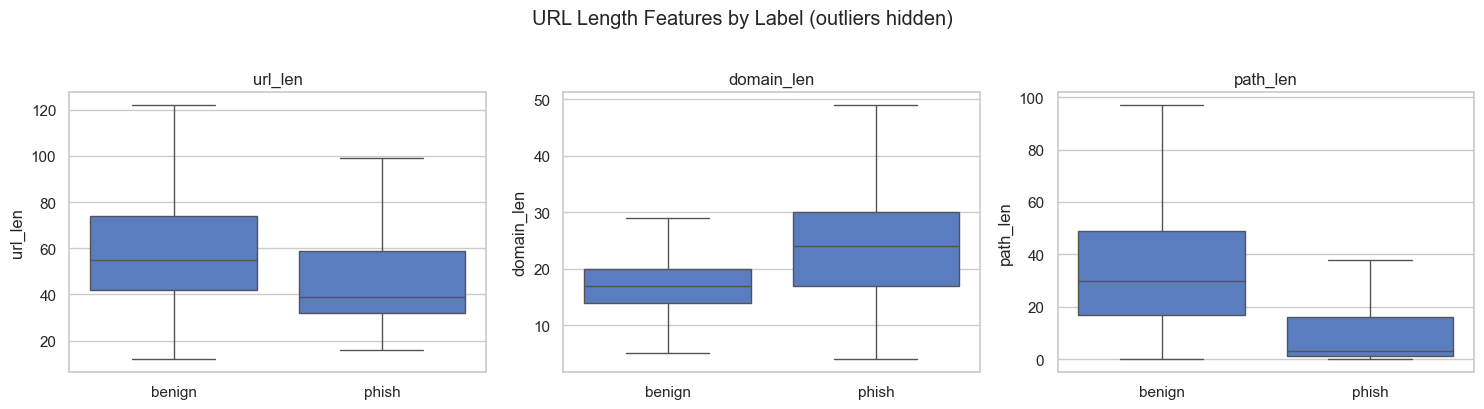

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["url_len", "domain_len", "path_len"]):
    sns.boxplot(data=df_url, x="label", y=col, ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("URL Length Features by Label (outliers hidden)", y=1.02)
plt.tight_layout()
plt.show()

HTML length statistics by label:
         count      mean       std    min      25%       50%       75%  \
label                                                                    
benign  5525.0  429601.0  573564.0  114.0  94458.0  253946.0  554323.0   
phish   4475.0  127771.0  378687.0   48.0   7444.0   36599.0  135375.0   

               max  
label               
benign  11431117.0  
phish    8361004.0  


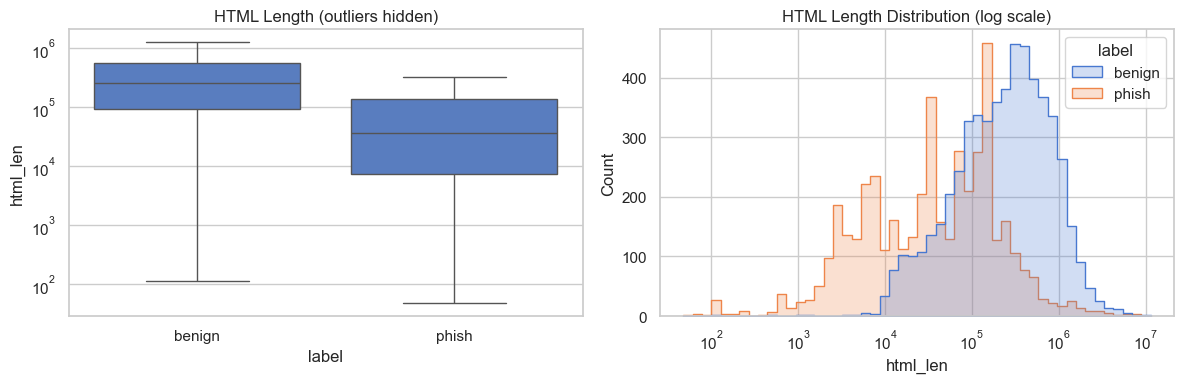


Approx. tags (from 400-char preview):
         count  mean  std  min  25%  50%  75%   max
label                                              
benign  5525.0   5.6  2.8  0.0  4.0  6.0  8.0  20.0
phish   4475.0   7.1  2.6  0.0  5.0  7.0  8.0  43.0


In [12]:
## 6. HTML Length & Basic Content Stats

# html_len was already calculated during the safe sampling step
print("HTML length statistics by label:")
print(df.groupby("label")["html_len"].describe().round(0))

# Optional: simple visualisation
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="label", y="html_len", ax=ax[0], showfliers=False)
ax[0].set_title("HTML Length (outliers hidden)")
ax[0].set_yscale("log")

sns.histplot(data=df, x="html_len", hue="label", bins=50, log_scale=True, ax=ax[1], element="step")
ax[1].set_title("HTML Length Distribution (log scale)")

plt.tight_layout()
plt.show()

# Very rough tag estimate from the short preview (optional)
if "html_preview" in df.columns:
    df["approx_tags"] = df["html_preview"].str.count(r"<[^>]+>")
    print("\nApprox. tags (from 400-char preview):")
    print(df.groupby("label")["approx_tags"].describe().round(1))

Top phishing targets:
 target
other        2670
facebook      379
meta          293
robinhood     109
usps           89
at&t           89
naver          80
whatsapp       77
booking        75
instagram      59
at&amp;t       28
netflix        22
microsoft      19
qmp            18
rakuten        18
Name: count, dtype: int64


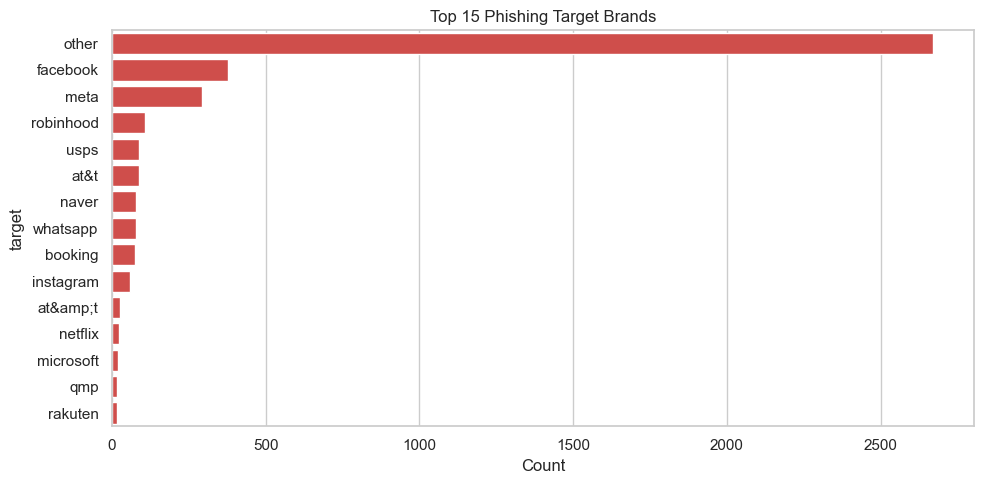

In [13]:
## 7. Target Brands (Phishing only)

if "target" in df.columns:
    phish = df[df["label"] == "phish"]
    top_targets = phish["target"].value_counts().head(15)
    print("Top phishing targets:\n", top_targets)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_targets.values, y=top_targets.index, orient="h", color="#e53935")
    plt.title("Top 15 Phishing Target Brands")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'target' not present.")

In [15]:
## 8. Quick Quality Checks

# - Extremely short HTML (using the pre-computed html_len)
# - Missing / empty URL
# - Duplicate SHA256 (if present)

print("HTML length < 100 chars :", (df["html_len"] < 100).sum())
print("HTML length == 0        :", (df["html_len"] == 0).sum())

print("Missing URL             :", df["url"].isna().sum())
print("Empty URL (after strip) :", (df["url"].astype(str).str.strip() == "").sum())

if "sha256" in df.columns:
    print("Duplicate SHA256        :", df["sha256"].duplicated().sum())
else:
    print("No sha256 column in this sample.")

# Extra useful checks
print("\nLabel value counts:")
print(df["label"].value_counts(dropna=False))

print("\nRows with missing target (benign pages normally have null):")
print(df["target"].isna().sum())

HTML length < 100 chars : 6
HTML length == 0        : 0
Missing URL             : 0
Empty URL (after strip) : 0
Duplicate SHA256        : 0

Label value counts:
label
benign    5525
phish     4475
Name: count, dtype: int64

Rows with missing target (benign pages normally have null):
5522


In [17]:
## 9. Sample Preview (URL + truncated HTML)

def preview_row(row):
    # Use the short preview we saved during sampling
    html_preview = str(row.get("html_preview", ""))[:300].replace("\n", " ")
    if len(html_preview) == 300:
        html_preview += "..."
    return f"[{row['label']}] {row['url']}\nHTML length: {row['html_len']:,} chars\n{html_preview}\n"

print("=" * 80)
for _, row in df.sample(5, random_state=42).iterrows():
    print(preview_row(row))
    print("-" * 80)

[phish] https://7364344444.github.io/Hgj/validation.html
HTML length: 4,293 chars
<html lang="en"><head>     <meta charset="UTF-8">     <link rel="icon" type="image/svg+xml" href="https://apply-get-verified-badge.vercel.app/assets/logo-xjw2vU6p.png">     <meta name="viewport" content="width=device-width, initial-scale=1.0">     <title>Meta Verified | Get a verified blue tick</tit...

--------------------------------------------------------------------------------
[benign] https://aggiemap.tamu.edu/
HTML length: 41,730 chars
<html lang="en" class="wf-opensans-n6-active wf-oswald-n5-active wf-oswald-n2-active wf-oswald-n3-active wf-opensans-n4-active wf-oswald-n4-active wf-materialicons-n4-active wf-materialiconsoutlined-n4-active wf-opensans-n3-active wf-active"><head>     <title>Aggie Map - Texas A&amp;M University</ti...

--------------------------------------------------------------------------------
[benign] https://www.facebook.com/SteinhafelsFurniture/
HTML length: 1,173,649 chars